In [ ]:
!pip install sentiment-analysis-spanish


In [ ]:
from sentiment_analysis_spanish import sentiment_analysis
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Cargamos Google Drive para acceder a los archivos
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Crea una instancia de la clase SentimentAnalysisSpanish para realizar el análisis de sentimientos
sentimiento= sentiment_analysis.SentimentAnalysisSpanish()

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:318: UserWarning: Trying to unpickle estimator CountVectorizer from version 0.23.2 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:318: UserWarning: Trying to unpickle estimator MultinomialNB from version 0.23.2 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
# Lee un archivo de Excel que contiene los tweets y los almacena en un DataFrame
df=pd.read_excel("/content/drive/MyDrive/Colab Notebooks/dataset_tweets.xlsx")

In [ ]:
# Aplica la función de análisis de sentimientos a cada tweet y guarda los resultados en una nueva columna llamada puntaje
df['puntaje'] = df['tweet'].apply(lambda x: sentimiento.sentiment(x))

In [ ]:
# Imprime la verificación del análisis de sentimientos para los primeros 10 tweets
print("Verificación del análisis de sentimientos:")
for i in range(10):
    print("Tweet:", df['tweet'][i])
    print("Sentimiento:", df['puntaje'][i])
    print()


Verificación del análisis de sentimientos:
Tweet: Para embarrar a la oposición en lo que sea y olvidemos de       es capaz de vender su alma al diablo para distraer quitar atención de los asuntos CORRUPTOS  
Sentimiento: 0.004157786509509182

Tweet:  Tuistar, chairos reconocit.
Sentimiento: 0.49789225920557484

Tweet:   “La vía de la concordia y la pacificación es el Derecho, la vía para ir arribando a un mejor país son los procesos judiciales. Sin Estado de Derecho no puede haber paz en nuestro país”: Ministro Presidente .  
Sentimiento: 0.8309338054152953

Tweet:       Recordemos el  de hace años cuando se trató el mismo tema. El gobierno de  saeta plagado de violaciones a derechos humanos y no pasa nada.
Sentimiento: 1.475592357398636e-06

Tweet:   Tú eres alguien de la Actual Administración del Gobierno de México? Cuál es tu puesto y contacto de oficina directo?  De no serlo, tu comentario sale sobrando porque lo único que denota es VENGANZA antes que SOLUCIÓN. 
Sentimiento: 6.6503

In [ ]:
# Filtra los tweets positivos y negativos según el puntaje
tweetspositivos = df[df['puntaje'] >= 0.7]
tweetsnegativos = df[df['puntaje'] <= 0.6]

In [ ]:
# Calcula diversas estadísticas sobre los tweets positivos y negativos
ntweetspositivos = tweetspositivos.shape[0]
ntweetsnegativos = tweetsnegativos.shape[0]
likestweetspositivos = tweetspositivos['nlikes'].sum()
likestweetsnegativos = tweetsnegativos['nlikes'].sum()

In [ ]:
retweetstweetspositivos = tweetspositivos['nretweets'].sum()
retweetstweetsnegativos = tweetsnegativos['nretweets'].sum()

In [ ]:
repliestweetspositivos = tweetspositivos['nreplies'].sum()
repliestweetsnegativos = tweetsnegativos['nreplies'].sum()

In [ ]:
print("Este es el número de tweets positivos:", ntweetspositivos)
print("Este es el número de tweets negativos:", ntweetsnegativos)
print("Este es el número de likes de los tweets positivos:", likestweetspositivos)
print("Este es el número de likes de los tweets negativos:", likestweetsnegativos)
print("Este es el número de retuits de los tweets positivos:", retweetstweetspositivos)
print(" Este es el número de retuits de los tweets negativos:", retweetstweetsnegativos)
print("Este es el número de replies positivos:", repliestweetspositivos)
print("Este es el número de replies negativos:", repliestweetsnegativos)

Este es el número de tweets positivos: 100
Este es el número de tweets negativos: 3861
Este es el número de likes de los tweets positivos: 759
Este es el número de likes de los tweets negativos: 131194
Este es el número de retuits de los tweets positivos: 287
 Este es el número de retuits de los tweets negativos: 41543
Este es el número de replies positivos: 78
Este es el número de replies negativos: 13649


In [ ]:
# Grafica el número de tweets positivos y negativos
categorias = ['Tweets positivos', 'Tweets negativos']
num_tweets = [len(tweetspositivos), len(tweetsnegativos)]
num_likes = [tweetspositivos['nlikes'].sum(), tweetsnegativos['nlikes'].sum()]
num_retweets = [tweetspositivos['nretweets'].sum(), tweetsnegativos['nretweets'].sum()]
num_replies = [tweetspositivos['nreplies'].sum(), tweetsnegativos['nreplies'].sum()]

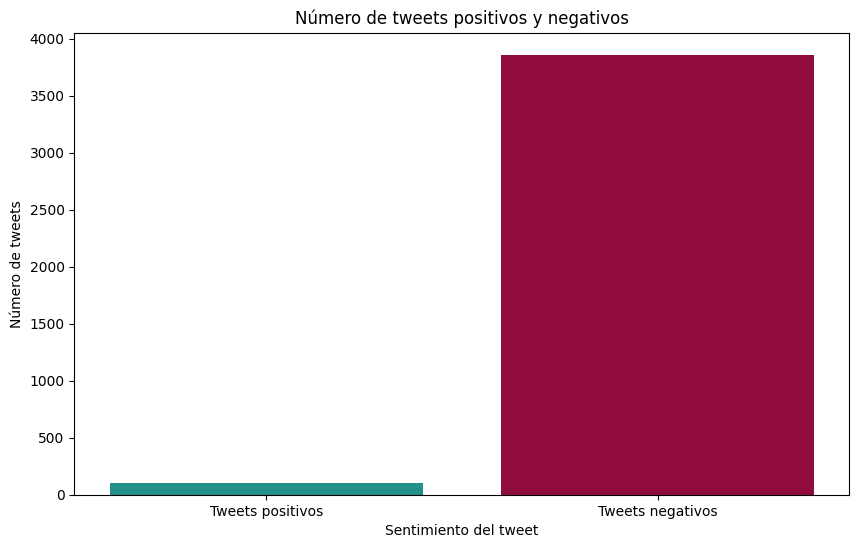

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(categorias, num_tweets, color=['#239089', '#900C3F'])
plt.xlabel('Sentimiento del tweet')
plt.ylabel('Número de tweets')
plt.title('Número de tweets positivos y negativos')
plt.show()

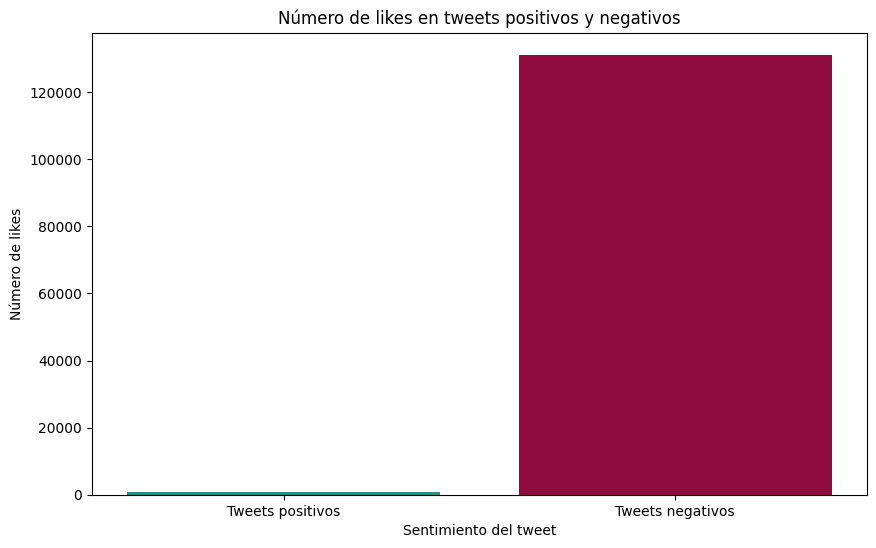

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(categorias, num_likes, color=['#239089', '#900C3F'])
plt.xlabel('Sentimiento del tweet')
plt.ylabel('Número de likes')
plt.title('Número de likes en tweets positivos y negativos')
plt.show()


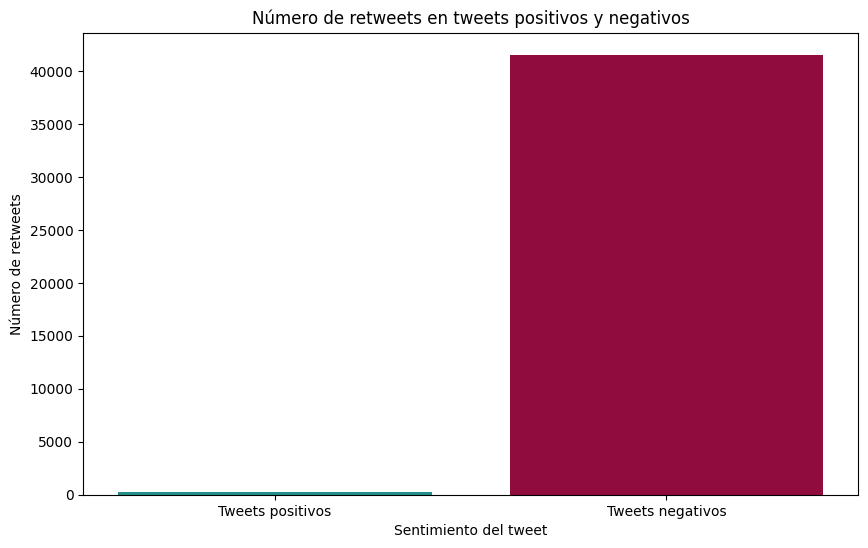

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(categorias, num_retweets, color=['#239089', '#900C3F'])
plt.xlabel('Sentimiento del tweet')
plt.ylabel('Número de retweets')
plt.title('Número de retweets en tweets positivos y negativos')
plt.show()

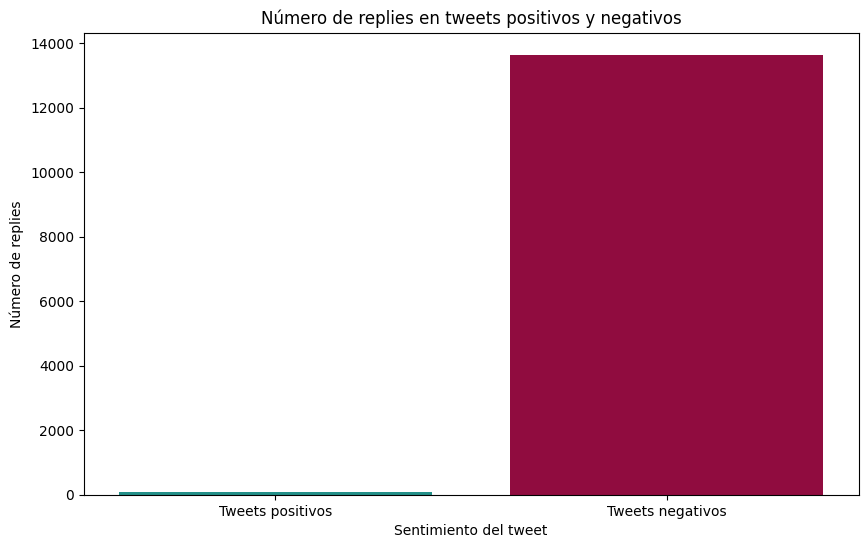

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(categorias, num_replies, color=['#239089', '#900C3F'])
plt.xlabel('Sentimiento del tweet')
plt.ylabel('Número de replies')
plt.title('Número de replies en tweets positivos y negativos')
plt.show()